In [ ]:
#########################################################################
########------ Ciencia de Datos e IA Generativa con Python ------########
#########################################################################
# Capacitador: Julio César Bernal Fernández
# email: juliobf08@gmail.com
# Tema : Laboratorio KMeans para Clustering
# versión: 1.0
#########################################################################

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

import pandas_datareader as pdr

In [2]:
# Descargar el dataset
import urllib.request
import zipfile

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip'
urllib.request.urlretrieve(url, 'bank-additional.zip')

('bank-additional.zip', <http.client.HTTPMessage at 0x7b01f9e337d0>)

In [4]:
# Leer el archivo zip
with zipfile.ZipFile('bank-additional.zip', 'r') as zip_ref:
    zip_ref.extractall()

# Leer el conjunto de datos
data = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')

In [7]:
print(f'Número de filas: {len(data)}')
data.head()

Número de filas: 41188


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


##Diccionario

* age: Edad del cliente (variable numérica).
* job: Profesión del cliente (variable categórica), que incluye categorías como "admin.", "blue-collar" (trabajador manual), "technician" (técnico), entre otras.
* marital: Estado civil del cliente (variable categórica), que puede ser "married" (casado), "single" (soltero), "divorced" (divorciado) o "unknown" (desconocido).
* education: Nivel de educación del cliente (variable categórica), como "basic.4y" (educación básica de 4 años), "university.degree" (licenciatura), "unknown" (desconocido), entre otros.
* default: Indicador de si el cliente tiene crédito por defecto o no (variable categórica).
* housing: Indicador de si el cliente tiene un préstamo de vivienda o no (variable categórica).
* loan: Indicador de si el cliente tiene un préstamo personal o no (variable categórica).
* contact: Método de contacto del cliente (variable categórica), que puede ser "cellular" (teléfono móvil) o "telephone" (teléfono fijo).
month: Mes del último contacto realizado con el cliente (variable categórica).
* day_of_week: Día de la semana del último contacto realizado con el cliente (variable categórica).
* duration: Duración en segundos del último contacto realizado con el cliente (variable numérica). Nota: este campo no debe ser considerado para un análisis predictivo, ya que está altamente correlacionado con el resultado (específicamente, la duración de la llamada depende del resultado de la llamada).
* campaign: Número de contactos realizados durante esta campaña y para este cliente (variable numérica).
* pdays: Número de días que han pasado desde el último contacto realizado con el cliente en una campaña anterior (variable numérica). Se establece a 999 si el cliente no fue contactado previamente.
* previous: Número de contactos realizados antes de esta campaña y para este cliente (variable numérica).
poutcome: Resultado de la campaña de marketing anterior (variable categórica).
* emp.var.rate: Tasa de variación del empleo (variable numérica).
* cons.price.idx: Índice de precios al consumidor (variable numérica).
* cons.conf.idx: Índice de confianza del consumidor (variable numérica).
* euribor3m: Tasa Euribor a 3 meses (variable numérica).
* nr.employed: Número de empleados (variable numérica).

In [8]:
len(data.columns.to_list())

21

In [9]:
# Seleccionar las características para el agrupamiento
X = data[['age', 'campaign']]

In [10]:
X.head()

,age,campaign
0,56,1
1,57,1
2,37,1
3,40,1
4,56,1


### **Train vs Test**

In [11]:
train_test_split(X, test_size=0.2, random_state=42)

[       age  campaign
 12556   40         2
 35451   31         4
 30592   59         6
 17914   43         5
 3315    39         2
 ...    ...       ...
 6265    58         2
 11284   37         1
 38158   35         1
 860     40         2
 15795   29         2
 
 [32950 rows x 2 columns],
        age  campaign
 32884   57         1
 3169    55         2
 32206   33         1
 9403    36         4
 14020   27         2
 ...    ...       ...
 12322   27         1
 23440   41         7
 29431   46        12
 16627   31         2
 1871    59         2
 
 [8238 rows x 2 columns]]

### **sklearn.model_selection**

In [12]:
# Dividir los datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [14]:
print(X.shape , X_train.shape , X_test.shape)

(41188, 2) (32950, 2) (8238, 2)


#K-Means

## Definicion de parámetros :

El algoritmo K-means es una técnica de agrupamiento (clustering) ampliamente utilizada y está disponible en la biblioteca de aprendizaje automático scikit-learn de Python. A continuación, se describen los parámetros más relevantes del algoritmo KMeans en scikit-learn:

1. n_clusters: Especifica el número de grupos (clusters) que se desean crear. Es un parámetro obligatorio y debe ser un valor entero positivo.

2. init: Determina el método utilizado para inicializar los centroides de los grupos. Puede tomar uno de los siguientes valores:

* "k-means++": Inicializa los centroides de manera inteligente para acelerar la convergencia.
* "random": Inicializa los centroides de forma aleatoria.

3. n_init: Especifica el número de veces que se ejecutará el algoritmo con diferentes centroides iniciales. El resultado final será el mejor de todas las ejecuciones en términos de la inercia.

4. max_iter: Indica el número máximo de iteraciones que realizará el algoritmo para converger. Si los centroides no convergen antes de alcanzar el número máximo de iteraciones, el algoritmo se detendrá.

5. tol: Especifica un valor de tolerancia para la convergencia. Si la diferencia entre las inercias de dos iteraciones consecutivas es menor o igual a esta tolerancia, se considera que el algoritmo ha convergido y se detiene.

6. random_state: Es un valor entero que permite controlar la generación de números aleatorios en el algoritmo. Esto garantiza que los resultados sean reproducibles.

In [22]:
# Modelo de Kmeans con 2 clusters
kmeans = KMeans(n_clusters=2,init='random', n_init=20)

In [23]:
kmeans.fit(X_train)

KMeans(init='random', n_clusters=2, n_init=20)

In [25]:
# Modelo de Kmeans con 2 clusters
kmeans = KMeans(n_clusters=3,init='random', n_init=20)
kmeans.fit(X_train)

KMeans(init='random', n_clusters=3, n_init=20)

In [26]:
kmeans.predict(X_train)

array([0, 1, 2, ..., 1, 0, 1], dtype=int32)

##Visualizar Los Clusters

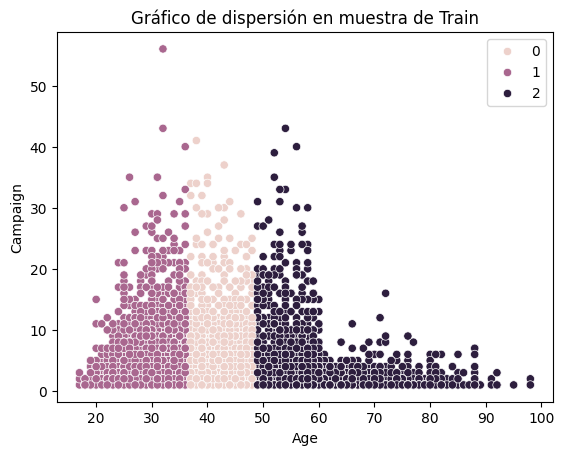

In [27]:
import matplotlib.pyplot as plt
# Crear el gráfico de dispersión utilizando Seaborn
sns.scatterplot(x=X_train['age'], y=X_train['campaign'], hue=kmeans.predict(X_train))

# Personalizar los ejes y el título
plt.xlabel('Age')
plt.ylabel('Campaign')
plt.title('Gráfico de dispersión en muestra de Train')

# Mostrar el gráfico
plt.show()

In [20]:
kmeans.predict(X_test)

array([1, 1, 2, ..., 0, 2, 1], dtype=int32)

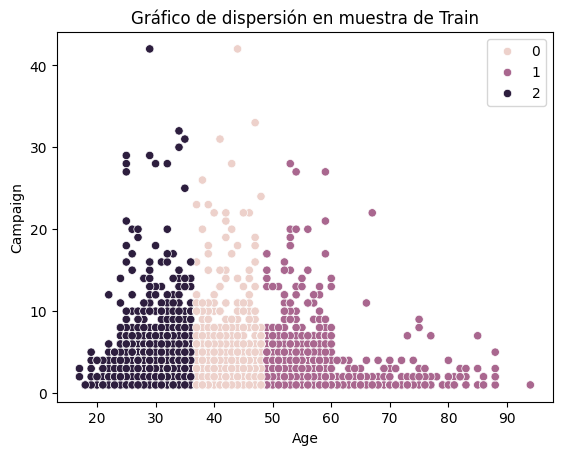

In [21]:
sns.scatterplot(x=X_test['age'], y=X_test['campaign'], hue=kmeans.predict(X_test))
# Personalizar los ejes y el título
plt.xlabel('Age')
plt.ylabel('Campaign')
plt.title('Gráfico de dispersión en muestra de Train')

# Mostrar el gráfico
plt.show()

#Dbscan

El algoritmo DBSCAN (Density-Based Spatial Clustering of Applications with Noise) es una técnica de agrupamiento que se basa en la densidad de los puntos en el espacio de características. La implementación de DBSCAN en scikit-learn proporciona varios parámetros que se pueden ajustar para controlar el comportamiento del algoritmo. A continuación, te proporcionaré una descripción de los parámetros más importantes del DBSCAN en scikit-learn:

1. eps: Especifica la distancia máxima entre dos puntos para que se consideren vecinos. Es un parámetro crítico que determina la densidad requerida para formar un grupo. Un valor de eps más pequeño resultará en grupos más densos.

2. min_samples: Especifica el número mínimo de puntos dentro de un radio eps para que un punto se considere un núcleo. Los puntos núcleo son aquellos que tienen suficientes vecinos dentro de su vecindario eps para formar un grupo. Un valor mayor de min_samples requerirá una mayor densidad para formar grupos.

3. metric: Especifica la métrica de distancia utilizada para medir la distancia entre los puntos. Puede ser una cadena de texto que representa una de las métricas de distancia disponibles en scikit-learn, como "euclidean", "manhattan", "cosine", entre otras.

4. n_jobs: Especifica el número de trabajos en paralelo para ejecutar el algoritmo. Puede acelerar el proceso en sistemas con múltiples núcleos de CPU. Un valor de -1 utilizará todos los núcleos disponibles.

In [28]:
# DBSCAN con eps = 1 y min_samples = 5
dbscan = DBSCAN(eps=1, min_samples=10 , metric ='manhattan')
dbscan.fit(X_train)

DBSCAN(eps=1, metric='manhattan', min_samples=10)

In [29]:
# Estandarización
X_train['age_std'] = (X_train['age'] - X_train['age'].mean()) / X_train['age'].std()

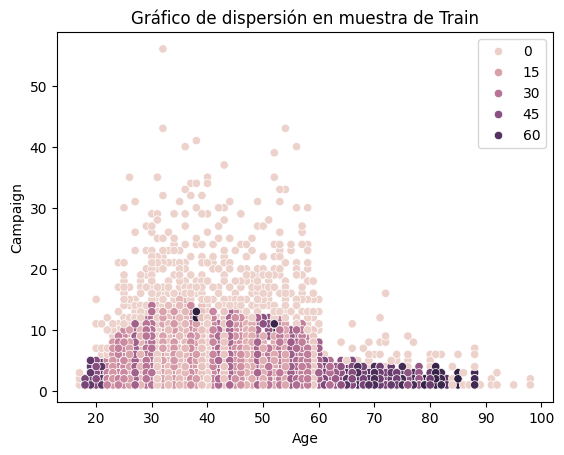

In [31]:
import matplotlib.pyplot as plt
# Crear el gráfico de dispersión utilizando Seaborn
sns.scatterplot(x=X_train['age'], y=X_train['campaign'], hue=dbscan.fit_predict(X_train))

# Personalizar los ejes y el título
plt.xlabel('Age')
plt.ylabel('Campaign')
plt.title('Gráfico de dispersión en muestra de Train')

# Mostrar el gráfico
plt.show()

# **Indicador de Silueta**
_Que tan bien están agrupados los grupos_

In [32]:
# Calcular el puntaje de silueta para k-means
kmeans_silhouette = silhouette_score(X_test, kmeans.predict(X_test))

# Calcular el puntaje de silueta para DBSCAN
dbscan_silhouette = silhouette_score(X_test, dbscan.fit_predict(X_test))

In [34]:
# Imprimir los puntajes de silueta
print("Puntaje de silueta para k-means: ", kmeans_silhouette)
print("Puntaje de silueta para DBSCAN: ", dbscan_silhouette) # -> Un valor negativo indica que están superpuestos.

Puntaje de silueta para k-means:  0.4851986587539412
Puntaje de silueta para DBSCAN:  -0.14671110447311558


# Predicción con el modelo final

In [35]:
predict = pd.DataFrame(kmeans.predict(X_test) , columns=['predict'])

In [36]:
predict.head()

,predict
0,2
1,2
2,1
3,1
4,1


In [37]:
predict = pd.DataFrame(kmeans.predict(X_test) , columns=['predict'])
pd.concat([X_test.reset_index(), predict.reset_index()], axis=1 )[['age','campaign','predict']].to_csv('k-means')

In [39]:
pd1 = pd.concat([X_test.reset_index(), predict.reset_index()], axis=1 )[['age','campaign','predict']]
pd1.head()

,age,campaign,predict
0,57,1,2
1,55,2,2
2,33,1,1
3,36,4,1
4,27,2,1


In [40]:
from itertools import product
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

param_grid = {'n_clusters': [2, 3, 4, 5,6,7,8],
              'init': ['k-means++', 'random'],
              'n_init': [10, 20, 30,40,50]}

# Generar todas las combinaciones de parámetros
combinations = list(product(*param_grid.values()))
print(combinations)

[(2, 'k-means++', 10), (2, 'k-means++', 20), (2, 'k-means++', 30), (2, 'k-means++', 40), (2, 'k-means++', 50), (2, 'random', 10), (2, 'random', 20), (2, 'random', 30), (2, 'random', 40), (2, 'random', 50), (3, 'k-means++', 10), (3, 'k-means++', 20), (3, 'k-means++', 30), (3, 'k-means++', 40), (3, 'k-means++', 50), (3, 'random', 10), (3, 'random', 20), (3, 'random', 30), (3, 'random', 40), (3, 'random', 50), (4, 'k-means++', 10), (4, 'k-means++', 20), (4, 'k-means++', 30), (4, 'k-means++', 40), (4, 'k-means++', 50), (4, 'random', 10), (4, 'random', 20), (4, 'random', 30), (4, 'random', 40), (4, 'random', 50), (5, 'k-means++', 10), (5, 'k-means++', 20), (5, 'k-means++', 30), (5, 'k-means++', 40), (5, 'k-means++', 50), (5, 'random', 10), (5, 'random', 20), (5, 'random', 30), (5, 'random', 40), (5, 'random', 50), (6, 'k-means++', 10), (6, 'k-means++', 20), (6, 'k-means++', 30), (6, 'k-means++', 40), (6, 'k-means++', 50), (6, 'random', 10), (6, 'random', 20), (6, 'random', 30), (6, 'random'

In [41]:
list(combinations[1])

[2, 'k-means++', 20]

In [42]:
#X_test

In [43]:
X_train.head()

,age,campaign,age_std
12556,40,2,-0.001669
35451,31,4,-0.864082
30592,59,6,1.818979
17914,43,5,0.285802
3315,39,2,-0.097493


In [44]:
X_test.head()

,age,campaign
32884,57,1
3169,55,2
32206,33,1
9403,36,4
14020,27,2


In [45]:
X_test['age_std'] = (X_test['age'] - X_test['age'].mean()) / X_test['age'].std()

In [46]:
combinations

[(2, 'k-means++', 10),
 (2, 'k-means++', 20),
 (2, 'k-means++', 30),
 (2, 'k-means++', 40),
 (2, 'k-means++', 50),
 (2, 'random', 10),
 (2, 'random', 20),
 (2, 'random', 30),
 (2, 'random', 40),
 (2, 'random', 50),
 (3, 'k-means++', 10),
 (3, 'k-means++', 20),
 (3, 'k-means++', 30),
 (3, 'k-means++', 40),
 (3, 'k-means++', 50),
 (3, 'random', 10),
 (3, 'random', 20),
 (3, 'random', 30),
 (3, 'random', 40),
 (3, 'random', 50),
 (4, 'k-means++', 10),
 (4, 'k-means++', 20),
 (4, 'k-means++', 30),
 (4, 'k-means++', 40),
 (4, 'k-means++', 50),
 (4, 'random', 10),
 (4, 'random', 20),
 (4, 'random', 30),
 (4, 'random', 40),
 (4, 'random', 50),
 (5, 'k-means++', 10),
 (5, 'k-means++', 20),
 (5, 'k-means++', 30),
 (5, 'k-means++', 40),
 (5, 'k-means++', 50),
 (5, 'random', 10),
 (5, 'random', 20),
 (5, 'random', 30),
 (5, 'random', 40),
 (5, 'random', 50),
 (6, 'k-means++', 10),
 (6, 'k-means++', 20),
 (6, 'k-means++', 30),
 (6, 'k-means++', 40),
 (6, 'k-means++', 50),
 (6, 'random', 10),
 (6, 

In [47]:
# Inicializar variable para guardar el mejor score y los mejores parámetros
best_score = -1
best_params = None

for params in combinations:
    kmeans = KMeans(n_clusters=params[0], init=params[1], n_init=params[2])
    kmeans.fit(X_train)
    score = silhouette_score(X_test, kmeans.predict(X_test))
    if score > best_score:
        best_score = score
        best_params = params

print("Los mejores parámetros son: ", best_params)
print("Con un silhouette score de: ", best_score)

Los mejores parámetros son:  (2, 'k-means++', 10)
Con un silhouette score de:  0.5738074769340191


In [48]:
best_params

(2, 'k-means++', 10)

In [50]:
kmeans = KMeans(n_clusters=best_params[0], init=best_params[1], n_init=best_params[2])
kmeans.fit(X_train)

KMeans(n_clusters=2, n_init=10)

# **Inercia**
---
_Suma de las distancias de cada registro a su "centroide"_

La inercia es una métrica utilizada en algoritmos de agrupamiento, como K-means, para evaluar la calidad del agrupamiento. Representa la suma de las distancias al cuadrado de cada punto al centroide de su grupo correspondiente. Cuanto menor sea la inercia, mejor será la calidad del agrupamiento.

La fórmula matemática para calcular la inercia es la siguiente:

Inercia = Σ(distancia(punto, centroide)²)

Donde:

* Σ representa la suma de todas las distancias al cuadrado de los puntos.
* distancia(punto, centroide) es la distancia euclidiana entre un punto y su centroide correspondiente.

El algoritmo de K-means busca minimizar la inercia al iterar y ajustar los centroides de los grupos para que estén lo más cerca posible de sus respectivos puntos. Una menor inercia indica que los puntos dentro de cada grupo están más cerca de su centroide, lo que sugiere una mejor separación y compacidad de los grupos.

Es importante destacar que la inercia es sensible al número de grupos y tiende a disminuir a medida que se incrementa el número de grupos. Por lo tanto, es útil combinar la inercia con otras métricas y técnicas, como la curva elbow o la silueta, para determinar el número óptimo de grupos en un problema de agrupamiento.

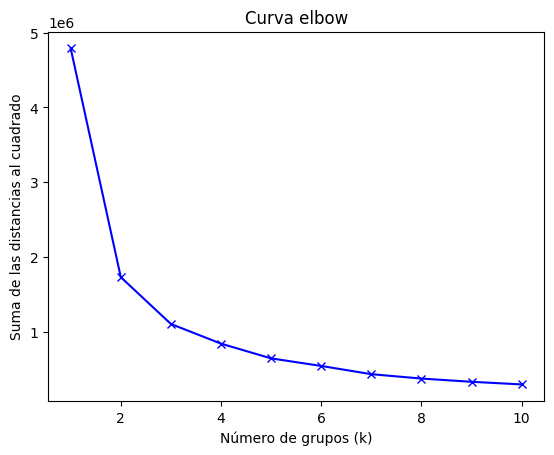

In [51]:
# Calcular la suma de las distancias al cuadrado para diferentes valores de k
distortions = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k,init='k-means++', n_init=10)
    kmeans.fit(X)
    distortions.append(kmeans.inertia_)

# Graficar la curva elbow
plt.plot(K, distortions, 'bx-')
plt.xlabel('Número de grupos (k)')
plt.ylabel('Suma de las distancias al cuadrado')
plt.title('Curva elbow')
plt.show()

In [52]:
# especificar los posibles valores para los parámetros
param_grid = {'eps': [0.1, 0.5, 1, 2],
              'min_samples': [3, 5, 10]}
